In [33]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import glob
import os
import warnings

# Paramètres de style pour des graphiques esthétiques et professionnels
warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams['figure.figsize'] = (14, 7)
plt.rcParams['font.size'] = 12

# 📊 Analyse Détaillée des Risques Mondiaux (World Risk Index)

L'objectif de cette analyse est de visualiser et d'explorer la base de données du **World Risk Index**, qui évalue les risques de catastrophes naturelles en croisant deux composantes essentielles :
1. **L'Exposition (E)** : la probabilité physique d'être touché par une catastrophe.
2. **La Vulnérabilité (V)** : la propension d'une société à subir des dommages, définie par la **Susceptibilité (S)**, le **Manque de capacités de réponse (C)** et le **Manque de capacités d'adaptation (A)**.

Nous chercherons à mettre en évidence **le lien direct entre la situation socio-économique d'un pays et son risque face aux catastrophes**.

In [34]:
# 1. Chargement et Agrégation des Données
all_files = glob.glob('Dataset/year_data/*.csv')
df_list = []

for f in all_files:
    temp_df = pd.read_csv(f)
    df_list.append(temp_df)

df = pd.concat(df_list, axis=0, ignore_index=True)

# S'assurer que les valeurs numériques sont correctement formatées si besoin
cols_numeriques = ['W', 'E', 'V', 'S', 'C', 'A']
for c in cols_numeriques:
    df[c] = pd.to_numeric(df[c], errors='coerce')

# Récupération de l'année la plus récente pour l'analyse spatiale (ex: 2025)
latest_year = df['Year'].max()
df_latest = df[df['Year'] == latest_year].dropna(subset=['W', 'E', 'V'])

print(f"Dataset consolidé. Nombre de lignes: {len(df)}. Année récente utilisée pour la cartographie : {latest_year}")

Dataset consolidé. Nombre de lignes: 5018. Année récente utilisée pour la cartographie : 2025.0


## 🌍 1. Cartographie Mondiale et Distribution Spatiale
Une vision globale permet immédiatement d'identifier les zones géographiques les plus exposées et les plus vulnérables.

In [35]:
# Graphique 1 : Carte Mondiale du WorldRiskIndex (W)
fig1 = px.choropleth(
    df_latest, 
    locations="ISO3.Code", 
    color="W", 
    hover_name="WRI.Country", 
    color_continuous_scale="Reds",
    title=f"🌐 Global WorldRiskIndex ({latest_year})",
    labels={'W': 'WorldRiskIndex'}
)
fig1.update_layout(geo=dict(showcoastlines=True), margin={"r":0,"t":40,"l":0,"b":0})
fig1.show()

In [36]:
# Graphique 2 : Carte Mondiale de la Vulnérabilité Socio-Économique (V)
fig2 = px.choropleth(
    df_latest, 
    locations="ISO3.Code", 
    color="V", 
    hover_name="WRI.Country", 
    color_continuous_scale="Purples",
    title=f"🛡️ Global Vulnerability ({latest_year})",
    labels={'V': 'Vulnerability'}
)
fig2.update_layout(geo=dict(showcoastlines=True), margin={"r":0,"t":40,"l":0,"b":0})
fig2.show()

In [37]:
# Graphique 3 : Carte Mondiale de l'Exposition aux Aléas (E)
fig3 = px.choropleth(
    df_latest, 
    locations="ISO3.Code", 
    color="E", 
    hover_name="WRI.Country", 
    color_continuous_scale="Oranges",
    title=f"⚡ Global Exposition ({latest_year})",
    labels={'E': 'Exposition'}
)
fig3.update_layout(geo=dict(showcoastlines=True), margin={"r":0,"t":40,"l":0,"b":0})
fig3.show()

## 🥇 2. Les Pays les Plus à Risque : Palmarès et Hiérarchies
Identifions les pays qui dominent malheureusement ces classements.

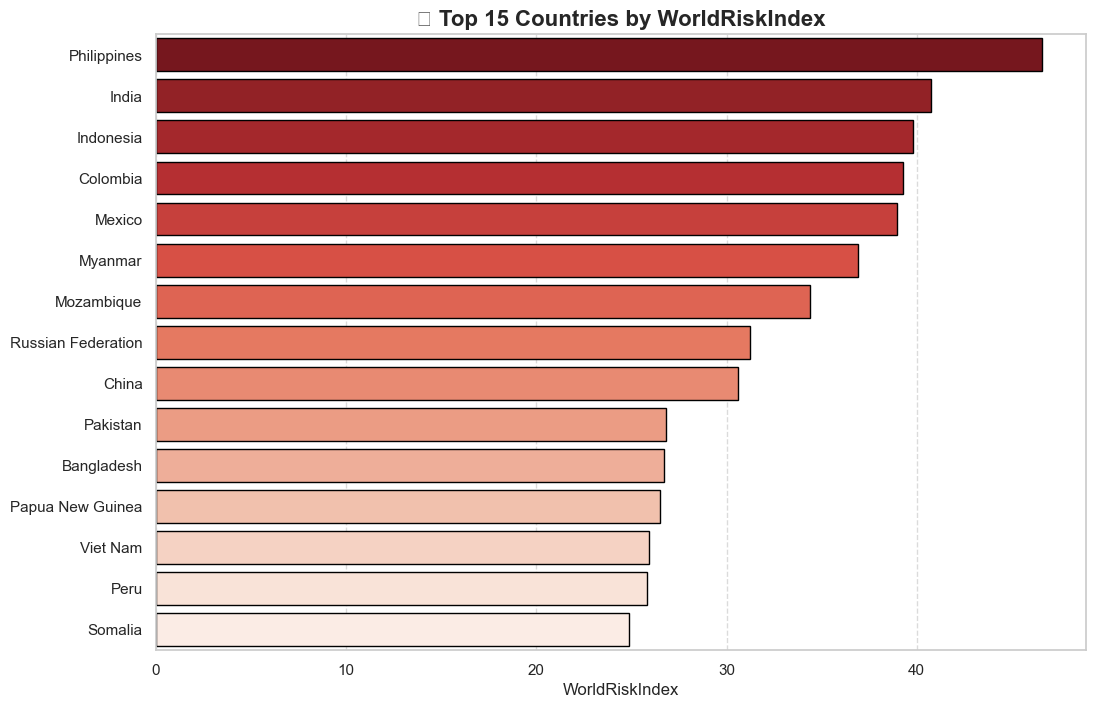

In [38]:
# Graphique 4 : Top 15 des pays avec le risque global le plus élevé
top_15_risk = df_latest.nlargest(15, 'W')

plt.figure(figsize=(12, 8))
sns.barplot(data=top_15_risk, x='W', y='WRI.Country', palette='Reds_r', edgecolor="black")
plt.title('🔴 Top 15 Countries by WorldRiskIndex', fontsize=16, fontweight='bold')
plt.xlabel('WorldRiskIndex')
plt.ylabel('')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

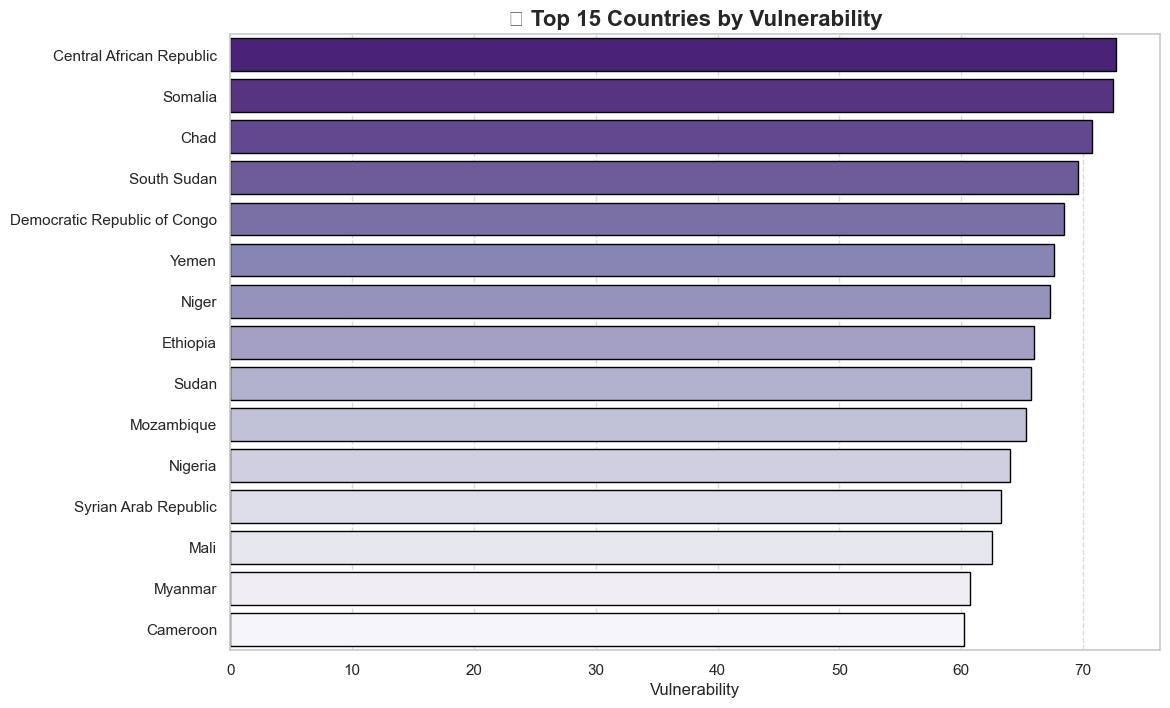

In [39]:
# Graphique 5 : Top 15 des pays les plus Vulnérables (Facteur socio-économique)
top_15_vuln = df_latest.nlargest(15, 'V')

plt.figure(figsize=(12, 8))
sns.barplot(data=top_15_vuln, x='V', y='WRI.Country', palette='Purples_r', edgecolor="black")
plt.title('🟣 Top 15 Countries by Vulnerability', fontsize=16, fontweight='bold')
plt.xlabel('Vulnerability')
plt.ylabel('')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

## 🌉 3. Croisement : Exposition vs Vulnérabilité (Le Coeur du Risque)
Comment une forte exposition couplée à une très mauvaise situation socio-économique engendre-t-elle un désastre potentiel ?

In [40]:
# Graphique 6 : Nuage de points interactif (Exposition vs Vulnérabilité)
fig4 = px.scatter(
    df_latest, x='E', y='V', size='W', color='W', hover_name='WRI.Country',
    color_continuous_scale='Turbo', size_max=40,
    title='🎯 Exposition vs Vulnerability',
    labels={'E': 'Exposition', 'V': 'Vulnerability', 'W': 'WorldRiskIndex'}
)
fig4.add_vline(x=df_latest['E'].median(), line_dash="dash", line_color="gray", annotation_text="Average Exposition")
fig4.add_hline(y=df_latest['V'].median(), line_dash="dash", line_color="gray", annotation_text="Average Vulnerability")
fig4.update_traces(marker=dict(line=dict(width=1, color='DarkSlateGrey')))
fig4.show()

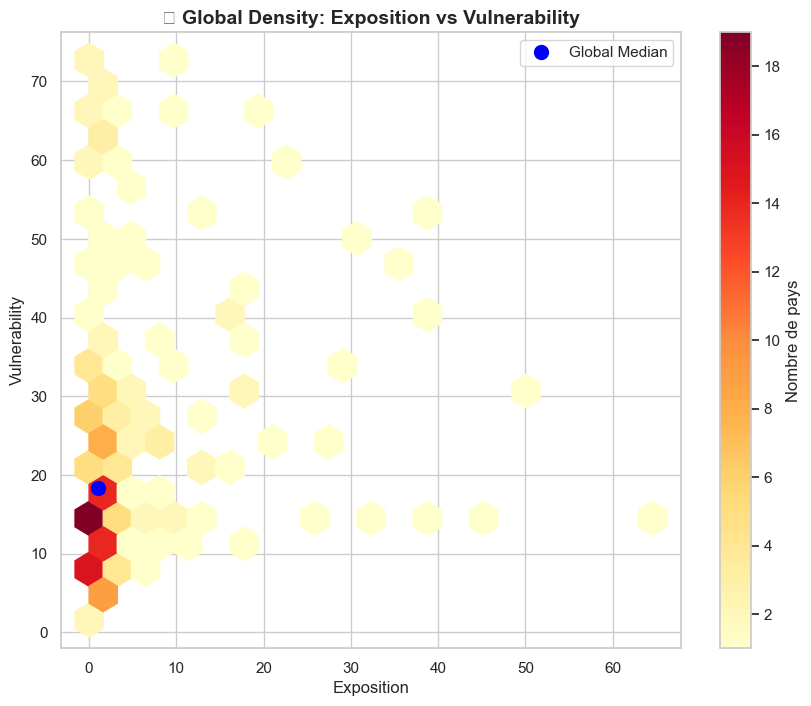

In [41]:
# Graphique 7 : Hexbin de la densité mondiale Vulnérabilité vs Exposition
plt.figure(figsize=(10, 8))
plt.hexbin(df_latest['E'], df_latest['V'], gridsize=20, cmap='YlOrRd', mincnt=1)
cb = plt.colorbar(label='Nombre de pays')
plt.xlabel('Exposition')
plt.ylabel('Vulnerability')
plt.title('🔥 Global Density: Exposition vs Vulnerability', fontsize=14, fontweight='bold')
plt.plot(df_latest['E'].median(), df_latest['V'].median(), 'bo', markersize=10, label="Global Median")
plt.legend()
plt.show()

## 🔍 4. Décomposition de la Vulnérabilité (S, C, A)
La vulnérabilité se décompose en facteurs économiques et d'infrastructures. Regardons leur impact profond.

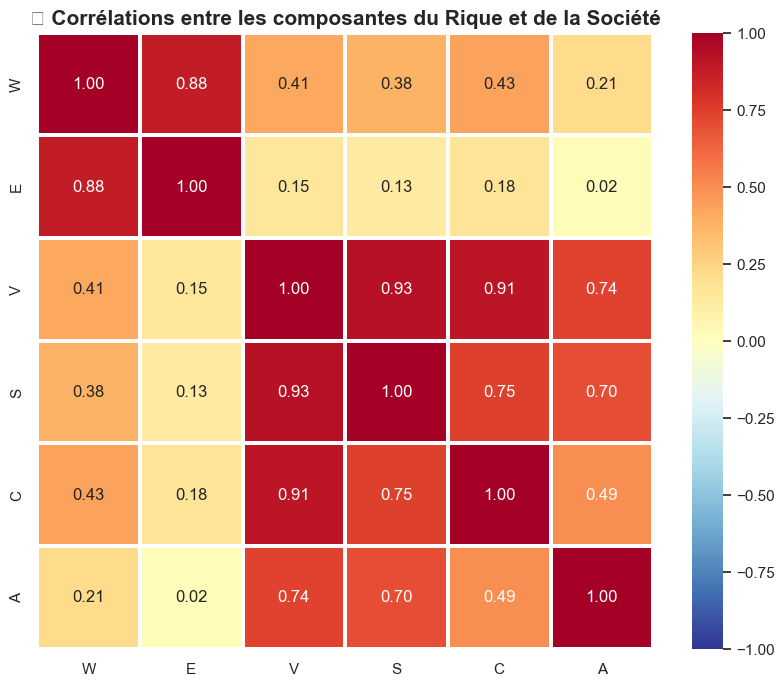

In [42]:
# Graphique 8 : Matrice de corrélation
plt.figure(figsize=(10, 8))
corr = df_latest[['W', 'E', 'V', 'S', 'C', 'A']].corr()
matrix = sns.heatmap(corr, annot=True, cmap='RdYlBu_r', fmt=".2f", linewidths=1.5, vmin=-1, vmax=1, square=True)
plt.title('🔗 Corrélations entre les composantes du Rique et de la Société', fontsize=15, fontweight='bold')
plt.show()

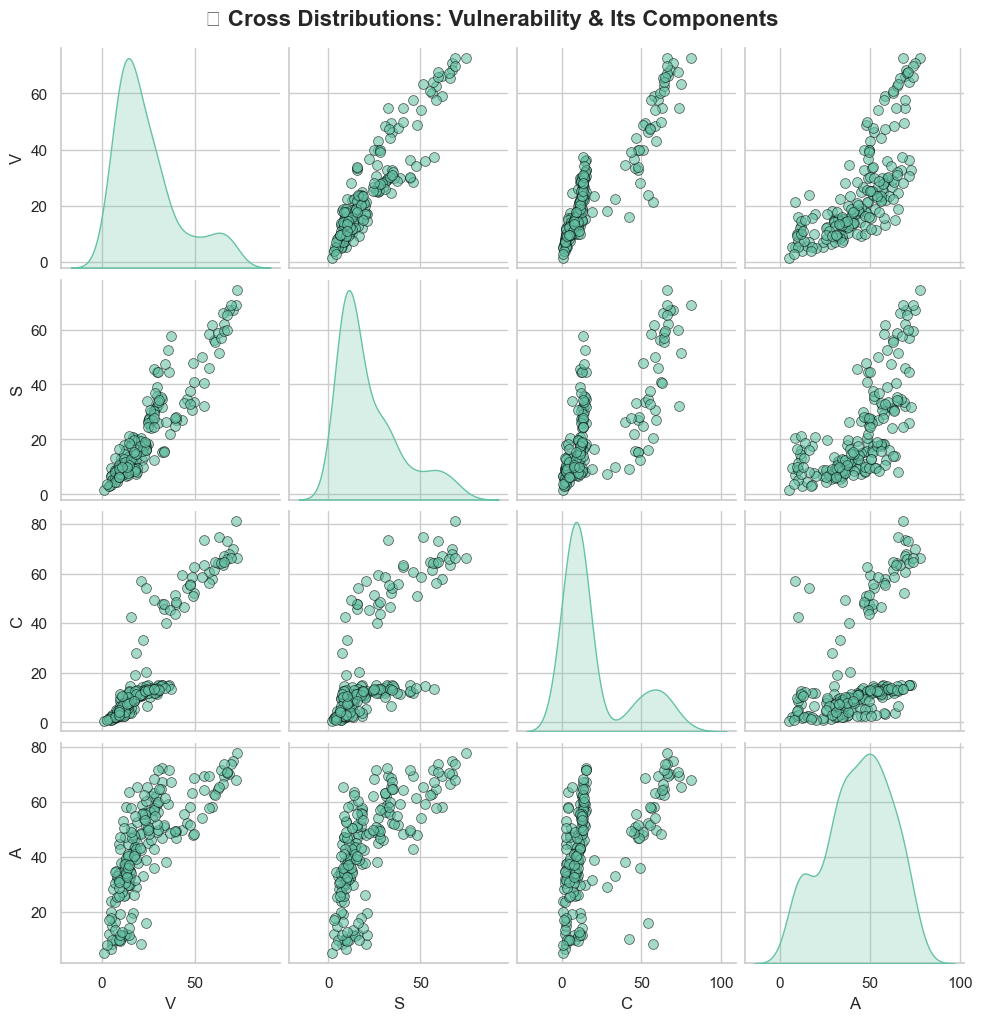

In [43]:
# Graphique 9 : Pairplot entre composants sociaux de la Vulnérabilité
g = sns.pairplot(
    df_latest[['V', 'S', 'C', 'A']], 
    diag_kind="kde",
    plot_kws={'alpha': 0.6, 's': 50, 'edgecolor': 'k'}
)
g.fig.suptitle("🧬 Cross Distributions: Vulnerability & Its Components", y=1.02, fontsize=16, fontweight='bold')
plt.show()

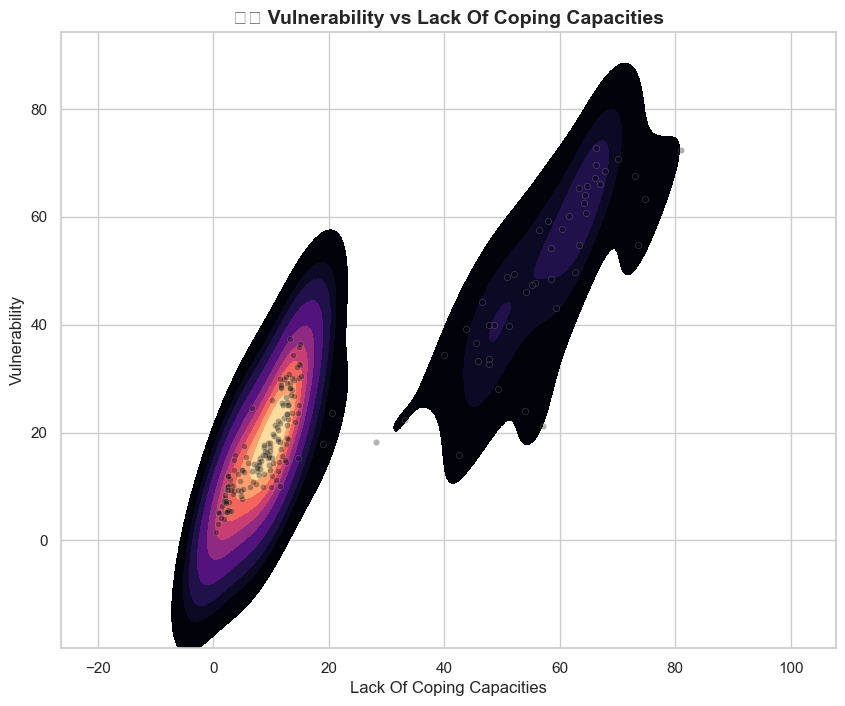

In [44]:
# Graphique 10 : Ridgeplot : Vulnérabilité Totale vs Manque de Capacités de Réponse (C - Coping Capacity)
plt.figure(figsize=(10, 8))
sns.kdeplot(x=df_latest['C'], y=df_latest['V'], cmap="magma", fill=True, thresh=0.05)
sns.scatterplot(x=df_latest['C'], y=df_latest['V'], color="black", alpha=0.3, s=20)
plt.title('🏗️ Vulnerability vs Lack Of Coping Capacities', fontsize=14, fontweight='bold')
plt.xlabel("Lack Of Coping Capacities")
plt.ylabel("Vulnerability")
plt.show()

## 📈 5. Distributions Internes : Les Maux de L'Humanité
Comparons la répartition globale des scores de faiblesses sociales et économiques.

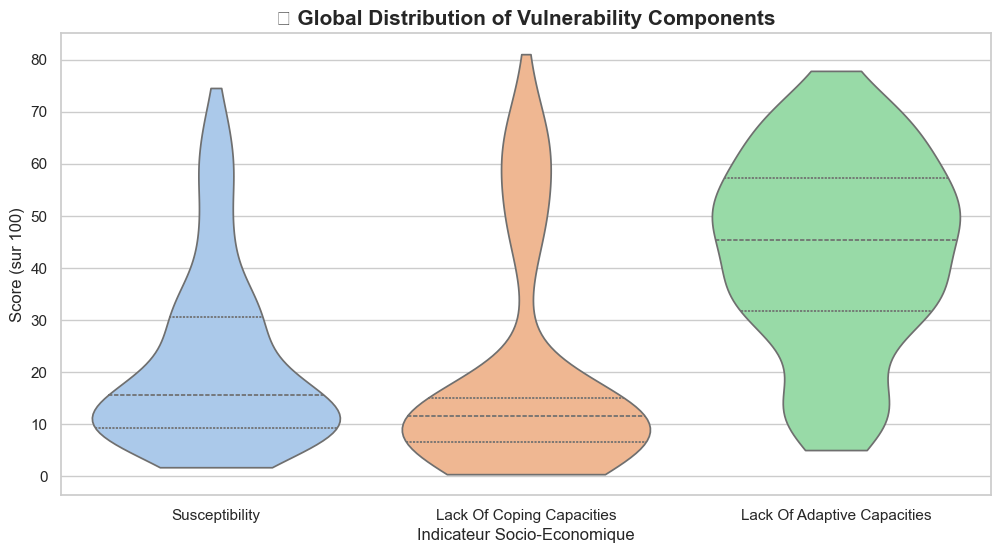

In [45]:
# Graphique 11 : Violons des Composantes Structurantes (S, C, A)
df_melted_vuln = df_latest.melt(
    id_vars=['WRI.Country'], 
    value_vars=['S', 'C', 'A'], 
    var_name='Indicateur Socio-Economique', 
    value_name='Score'
)

plt.figure(figsize=(12, 6))
sns.violinplot(
    x='Indicateur Socio-Economique', y='Score', data=df_melted_vuln, 
    palette='pastel', inner="quart", cut=0
)
plt.title('🎻 Global Distribution of Vulnerability Components', fontsize=15, fontweight='bold')
plt.xticks(ticks=[0, 1, 2], labels=['Susceptibility', 'Lack Of Coping Capacities', 'Lack Of Adaptive Capacities'])
plt.ylabel('Score (sur 100)')
plt.show()

In [46]:
# Graphique 12 : Jauge Radar des Moyennes Globales
means = df_latest[['S', 'C', 'A']].mean()

fig5 = go.Figure()
fig5.add_trace(go.Bar(
    y=['Susceptibility', 'Lack Of Coping Capacities', 'Lack Of Adaptive Capacities'],
    x=means.values,
    orientation='h',
    marker=dict(color=['#66c2a5', '#fc8d62', '#8da0cb']),
    text=round(means, 1),
    textposition='auto'
))
fig5.update_layout(
    title='📊 Global Averages: Vulnerability Components',
    xaxis_title='Score Moyen Mondial',
    yaxis_title=''
)
fig5.show()

## ⏳ 6. Tendances dans le Temps (Séries Temporelles)
Comment les risques et les situations économiques ont-ils évolués sur la période enregistrée ?

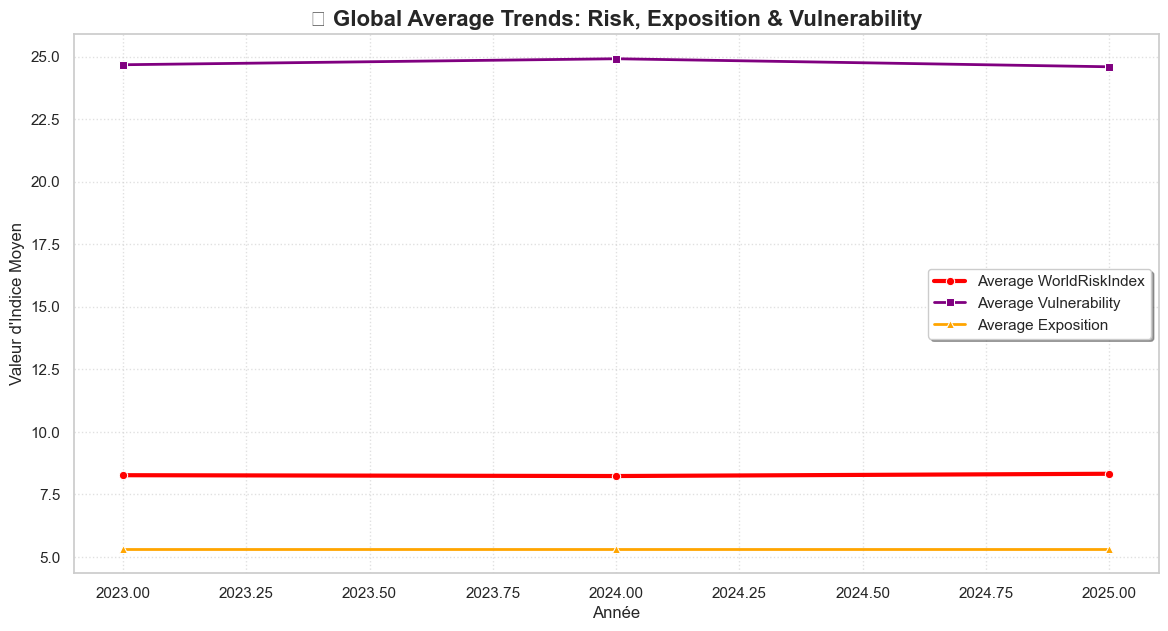

In [47]:
# Graphique 13 : Évolution des moyennes mondiales (W, E, V)
import matplotlib.ticker as ticker
yearly_means = df.groupby('Year')[['W', 'E', 'V']].mean().reset_index()

plt.figure(figsize=(14, 7))
sns.lineplot(data=yearly_means, x='Year', y='W', label='Average WorldRiskIndex', color='red', linewidth=3, marker='o')
sns.lineplot(data=yearly_means, x='Year', y='V', label='Average Vulnerability', color='purple', linewidth=2, marker='s')
sns.lineplot(data=yearly_means, x='Year', y='E', label='Average Exposition', color='orange', linewidth=2, marker='^')
plt.title('📉 Global Average Trends: Risk, Exposition & Vulnerability', fontsize=16, fontweight='bold')
plt.xlabel('Année')
plt.ylabel('Valeur d\'Indice Moyen')
plt.legend(frameon=True, shadow=True)
plt.grid(True, linestyle=":", alpha=0.6)
plt.gca().xaxis.set_major_locator(ticker.MaxNLocator(integer=True))
plt.show()

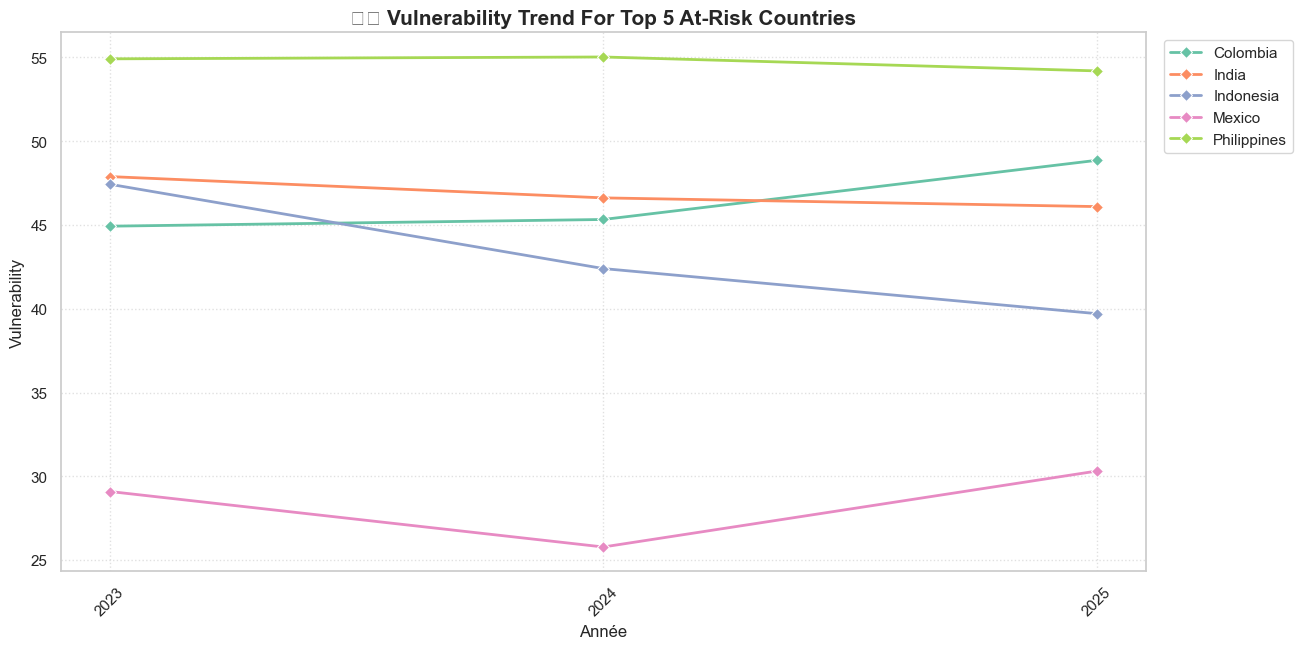

In [50]:
# Graphique 14 : Évolution de la Vulnérabilité (Socio-Économique) pour le TOP 5 Pays à haut risque actuels
import matplotlib.ticker as ticker

top_5_countries = top_15_risk.head(5)['WRI.Country'].tolist()
df_top_5 = df[df['WRI.Country'].isin(top_5_countries)].sort_values(by='Year')

plt.figure(figsize=(14, 7))
sns.lineplot(data=df_top_5, x='Year', y='V', hue='WRI.Country', marker='D', linewidth=2)
plt.title('🛡️ Vulnerability Trend For Top 5 At-Risk Countries', fontsize=15, fontweight='bold')
plt.xlabel('Année')
plt.ylabel('Vulnerability')
plt.legend(bbox_to_anchor=(1.01, 1), loc='upper left')
plt.gca().xaxis.set_major_locator(ticker.MaxNLocator(integer=True))
plt.xticks(sorted(df['Year'].dropna().unique()), rotation=45)
plt.grid(True, linestyle=":", alpha=0.6)
plt.show()

## 📝 Conclusion Visuelle Finale
Les graphiques montrent sans équivoque que si l'exposition physique aux désastres est inévitable (et distribuée selon la géographie et les aléas climatiques), **le véritable amplificateur du risque mondial est la pauvreté, le manque d'infrastructures et d'institutions fortes (La Vulnérabilité V, combinant S, C, et A)**. Les pays les plus à risque ne sont parfois pas les plus exposés, mais systématiquement ceux ayant les tissus socio-économiques les plus fragiles.

## 🌪️ 7. Segmentation par Types d'Exposition (Aléas Naturels)
Dans le jeu de données, les variables `EI_01` à `EI_07` représentent très probablement les sous-indicateurs d'exposition à différents types de catastrophes naturelles (ex: séismes, cyclones, inondations, sécheresses, etc.). Bien que la documentation exacte ne les nomme pas explicitement, nous pouvons observer la distribution et le lien entre ces risques individuels et la vulnérabilité globale.

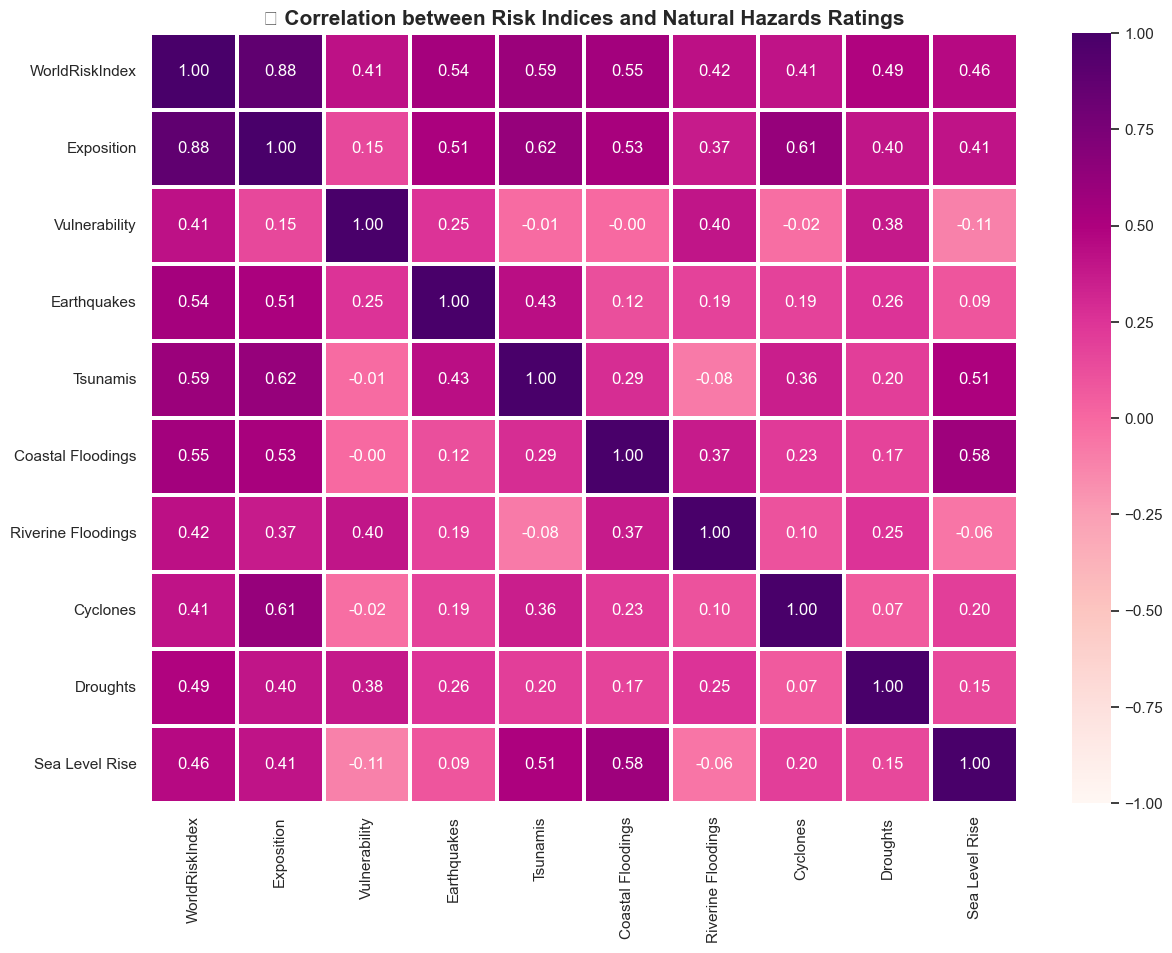

In [51]:
# Graphique 15 : Heatmap de corrélation étendue avec les sous-indicateurs d'exposition (EI)
# Filtrer les colonnes EI
ei_cols = [col for col in df_latest.columns if col.startswith('EI_0') and '_' not in col[3:]]
# Filtrer pour ne garder que EI_01 à EI_07 par exemple
ei_cols = [col for col in ei_cols if len(col) == 5]
cols_to_correlate = ['W', 'E', 'V'] + ei_cols

plt.figure(figsize=(14, 10))
corr_ei = df_latest[cols_to_correlate].rename(columns={'EI_01': 'Earthquakes', 'EI_02': 'Tsunamis', 'EI_03': 'Coastal Floodings', 'EI_04': 'Riverine Floodings', 'EI_05': 'Cyclones', 'EI_06': 'Droughts', 'EI_07': 'Sea Level Rise', 'W': 'WorldRiskIndex', 'E': 'Exposition', 'V': 'Vulnerability'}).corr()
sns.heatmap(corr_ei, annot=True, cmap='RdPu', fmt=".2f", linewidths=1.5, vmin=-1, vmax=1)
plt.title('🔥 Correlation between Risk Indices and Natural Hazards Ratings', fontsize=15, fontweight='bold')
plt.show()

## ⏳ 8. Cartes Animées : L\'Évolution Temporelle Interractive (2000-2025)
Utilisons les pleines capacités de Plotly pour voyager dans le temps, voir l'évolution du risque et comment la géopolitique et l'économie en constante mutation rendent les pays plus – ou moins – vulnérables !

In [ ]:
# Graphique 16 : Carte Animée Mondiale dans le temps : Indice de Risque
# Assurons-nous que le dataset complet est trié par année
df_anim = df.sort_values(by='Year').copy()

fig_anim1 = px.choropleth(
    df_anim, 
    locations="ISO3.Code", 
    color="W", 
    hover_name="WRI.Country", 
    animation_frame="Year", 
    color_continuous_scale="Reds",
    range_color=[df['W'].min(), df['W'].quantile(0.95)], # Fixer l'échelle globale (quantile pour éviter les outliers)
    title="🎬 WorldRiskIndex Evolution (2000-2025)",
    labels={'W': 'WorldRiskIndex'}
)
fig_anim1.update_layout(geo=dict(showcoastlines=True), margin={"r":0,"t":40,"l":0,"b":0})
fig_anim1.show()

## 📊 9. Top Gagnants et Perdants du 21e Siècle (Décalage de Vulnérabilité)
Lesquels ont le plus amélioré leur capacité de réponse entre l'année 2000 et l'année 2025 (preuve d'évolution socio-économique) ?

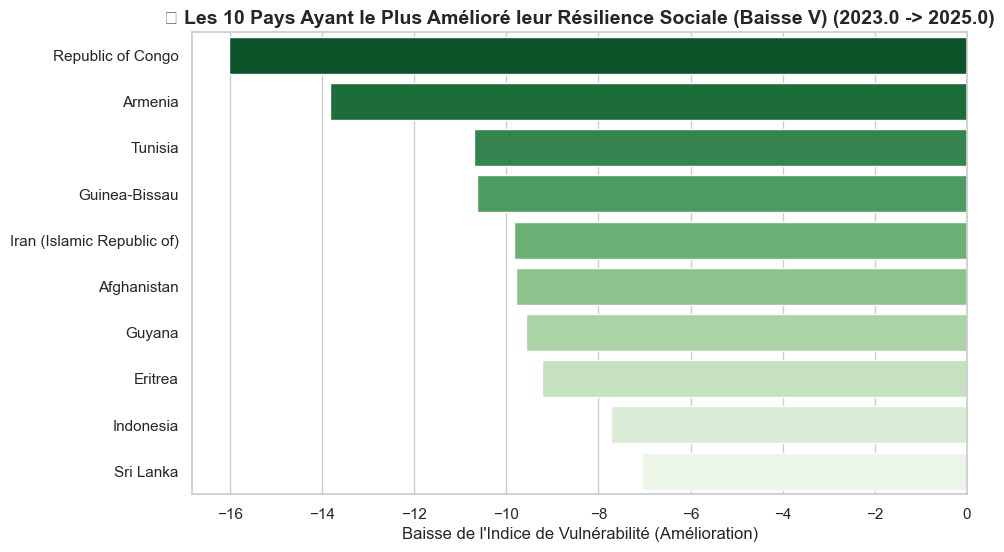

In [ ]:
# Préparation des données d'évolution E, V et W
min_year = df['Year'].min()
max_year = df['Year'].max()

df_start = df[df['Year'] == min_year][['WRI.Country', 'W', 'V', 'C', 'ISO3.Code']].set_index('WRI.Country')
df_end = df[df['Year'] == max_year][['WRI.Country', 'W', 'V', 'C']].set_index('WRI.Country')

# Fusionner en calculant la différence Différence = Fin - Début 
diff_df = df_end.join(df_start, lsuffix='_End', rsuffix='_Start').dropna()
diff_df['Diff_V'] = diff_df['V_End'] - diff_df['V_Start']
diff_df['Diff_W'] = diff_df['W_End'] - diff_df['W_Start']

diff_df = diff_df.reset_index()

# 1. Les 10 qui ont le plus baissé leur vulnérabilité (Amélioration !)
top_improvers = diff_df.sort_values(by='Diff_V', ascending=True).head(10)
# 2. Les 10 dont la vulnérabilité a le plus augmenté (Dégradation)
top_degraders = diff_df.sort_values(by='Diff_V', ascending=False).head(10)

# Graphique 17 : Top Améliorations de Vulnérabilité
plt.figure(figsize=(10, 6))
sns.barplot(data=top_improvers, x='Diff_V', y='WRI.Country', palette='Greens_r')
plt.title(f'🟢 Top 10 Countries with Best Vulnerability Improvement ({min_year} -> {max_year})', fontsize=14, fontweight='bold')
plt.xlabel('Vulnerability Decrease')
plt.ylabel('')
plt.show()

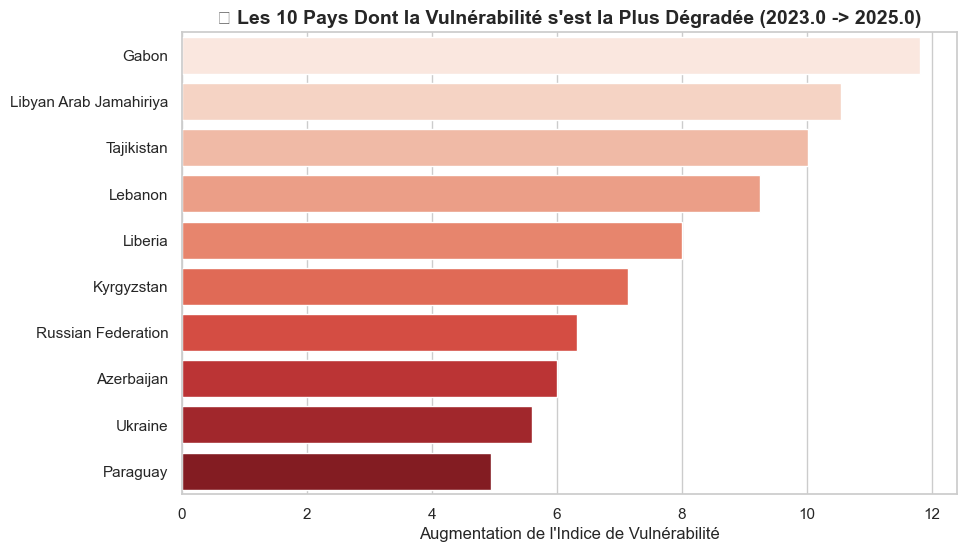

In [ ]:
# Graphique 18 : Dégradations Sensibles
plt.figure(figsize=(10, 6))
sns.barplot(data=top_degraders, x='Diff_V', y='WRI.Country', palette='Reds')
plt.title(f'🔴 Top 10 Countries with Worst Vulnerability Degradation ({min_year} -> {max_year})', fontsize=14, fontweight='bold')
plt.xlabel('Vulnerability Increase')
plt.ylabel('')
plt.show()

## 🎯 10. Segmentation Temporelle via Boxplots et Anomalies
Les "outliers" (valeurs aberrantes) représentent parfois des événements dramatiques très ciblés sur le spectre temporel ou géographique. Observons la variation mondiale par décennies/tranches d'années.

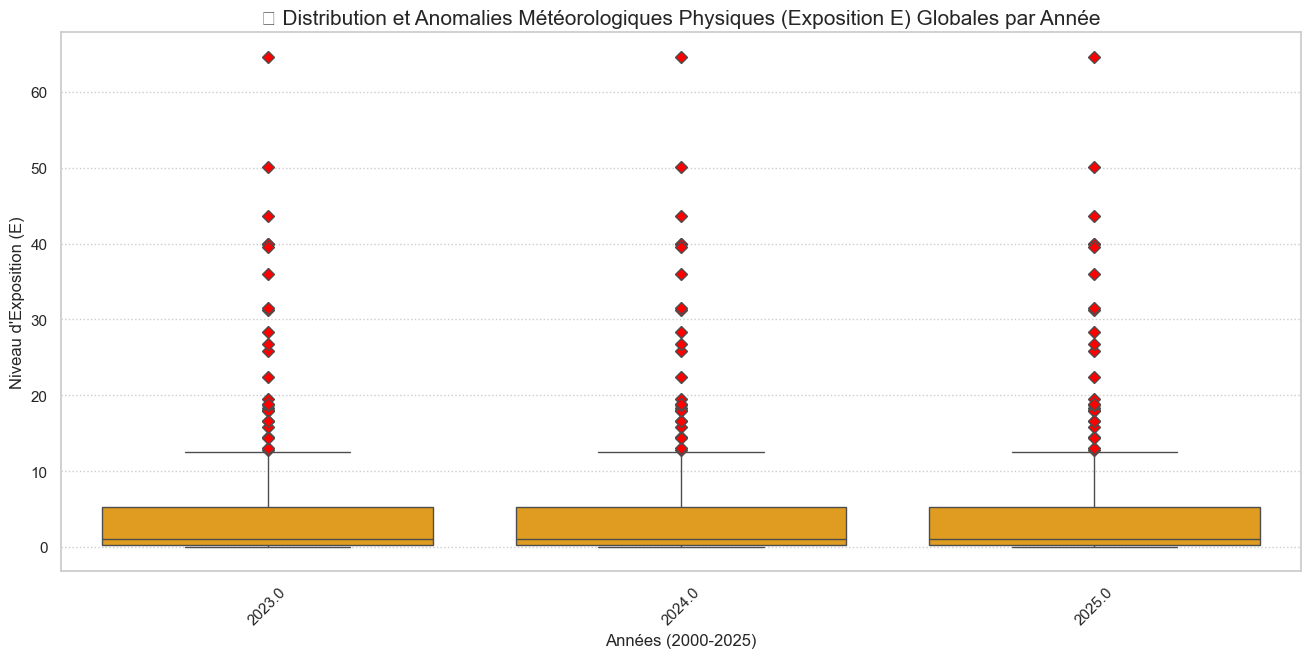

In [ ]:
# Graphique 19 : Boxplots de l'Exposition Totale (E) Année par Année
plt.figure(figsize=(16, 7))
sns.boxplot(x='Year', y='E', data=df, color='orange', flierprops=dict(markerfacecolor='red', marker='D'))
plt.title("📦 Exposition Distributions and Outliers (2000-2025)", fontsize=15)
plt.ylabel("Exposition")
plt.xlabel("Années (2000-2025)")
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle=':')
plt.show()